# Importing functions and utilities

In [8]:
# Importing required libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import joblib # for saving the parameter of linear regression model
from statsmodels.tsa.stattools import adfuller, kpss

from fracdiff.sklearn import Fracdiff
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from tqdm import tqdm 

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Importing functions from mypackage
from mypackage_utils import *

In [9]:
# Importing dataset of sp500
sp500  = joblib.load("sp500_updated.pkl")

In [10]:
def train_sp500_fd(weight_filename, train_set, val_set, test_set, target_train, target_val, target_test):
    # Transforming data into tensor 
    train_set = torch.tensor(train_set, dtype=torch.float32)
    val_set = torch.tensor(val_set, dtype=torch.float32)
    test_set = torch.tensor(test_set, dtype=torch.float32)
    target_train = torch.tensor(target_train, dtype=torch.float32).view(-1, 1)
    target_val = torch.tensor(target_val, dtype=torch.float32).view(-1, 1)
    target_test = torch.tensor(target_test, dtype=torch.float32).view(-1, 1)
    
    # Define the MLP model
    nhidden = 32
    model = nn.Sequential(nn.Linear(4, nhidden),
                            nn.ReLU(),
                            nn.Linear(nhidden, 1))
    # Dataset e DataLoader
    train_dataset = TensorDataset(train_set, target_train)
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False) # Shuffle False because of time series data

    # Defining loss, optimizer 
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    n_epochs = 1000
    # Training loop
    train_curve, val_curve = [], []
    training_loop = tqdm(range(n_epochs)) 
    for epoch in training_loop:
        # Training mode
        model.train() 
        running = 0.0 
        for batch_data, batch_targets in train_loader:
            # Reset computation graph
            optimizer.zero_grad()
            # Forward pass
            outputs = model(batch_data)
            # Compute training loss on batch
            loss = criterion(outputs, batch_targets)
            # Compute gradient 
            loss.backward()
            # Gradient step
            optimizer.step()
            # Loss per batch 
            running += loss.item()
        # Loss per epoch
        train_epoch = running / len(train_loader)

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(val_set)
            val_loss = criterion(val_outputs, target_val).item()

        # Store train and validation loss
        train_curve.append(train_epoch)
        val_curve.append(val_loss)

        # Print loss in the progression bar
        training_loop.set_postfix(train=train_epoch, val=val_loss, lr=optimizer.param_groups[0]['lr'])

    # Save the final model weights
    torch.save(model.state_dict(), weight_filename)
    # Plot losses
    plt.figure()
    plt.plot(train_curve, label='train')
    plt.plot(val_curve,   label='val')
    plt.yscale('log') 
    plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
    plt.show()			

    # Metrics evaluation 
    model.load_state_dict(torch.load(weight_filename)) 
    model.eval()
    with torch.no_grad():
        predictions = model(test_set).detach().numpy() 
        test_loss = mean_squared_error(target_test.numpy(), predictions)
        test_rmse = np.sqrt(test_loss)
        test_mae = mean_absolute_error(target_test.numpy(), predictions)

    return [test_loss, test_rmse, test_mae, predictions]
	
def train_sp500_d(weight_filename, train_set, val_set, test_set, target_train, target_val, target_test):
    # Transforming data into tensor 
    train_set = torch.tensor(train_set, dtype=torch.float32)
    val_set = torch.tensor(val_set, dtype=torch.float32)
    test_set = torch.tensor(test_set, dtype=torch.float32)
    target_train = torch.tensor(target_train, dtype=torch.float32).view(-1, 1)
    target_val = torch.tensor(target_val, dtype=torch.float32).view(-1, 1)
    target_test = torch.tensor(target_test, dtype=torch.float32).view(-1, 1)
    
    # Define the MLP model
    nhidden = 32
    model = nn.Sequential(nn.Linear(4, nhidden),
                                nn.ReLU(),
                                nn.Linear(nhidden, nhidden),
                                nn.ReLU(),
                                nn.Linear(nhidden, 1))
    # Dataset e DataLoader
    train_dataset = TensorDataset(train_set, target_train)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False) # Shuffle False because of time series data

    # Defining loss, optimizer 
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    n_epochs = 700
    # Training loop
    train_curve, val_curve = [], []
    training_loop = tqdm(range(n_epochs)) 
    for epoch in training_loop:
        # Training mode
        model.train() 
        running = 0.0 
        for batch_data, batch_targets in train_loader:
            # Reset computation graph
            optimizer.zero_grad()
            # Forward pass
            outputs = model(batch_data)
            # Compute training loss on batch
            loss = criterion(outputs, batch_targets)
            # Compute gradient 
            loss.backward()
            # Gradient step
            optimizer.step()
            # Loss per batch 
            running += loss.item()
        # Loss per epoch
        train_epoch = running / len(train_loader)

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(val_set)
            val_loss = criterion(val_outputs, target_val).item()

        # Store train and validation loss
        train_curve.append(train_epoch)
        val_curve.append(val_loss)

        # Print loss in the progression bar
        training_loop.set_postfix(train=train_epoch, val=val_loss, lr=optimizer.param_groups[0]['lr'])

    # Save the final model weights
    torch.save(model.state_dict(), weight_filename)
    # Plot losses
    plt.figure()
    plt.plot(train_curve, label='train')
    plt.plot(val_curve,   label='val')
    plt.yscale('log') 
    plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
    plt.show()			

    # Metrics evaluation 
    model.load_state_dict(torch.load(weight_filename)) 
    model.eval()
    with torch.no_grad():
        predictions = model(test_set).detach().numpy() 
        test_loss = mean_squared_error(target_test.numpy(), predictions)
        test_rmse = np.sqrt(test_loss)
        test_mae = mean_absolute_error(target_test.numpy(), predictions)

    return [test_loss, test_rmse, test_mae, predictions]

def simulate_trading_sp500(predictions):
    # If instead of predicting the log-close, I predict the log-return
    # Initialize daily profit/loss (PnL)
    daily_pnl = []
    actual_price = sp500['Close'].iloc[-len(predictions)-1:].values.astype(float)
    # If predictions[i] > 0 => P_t+1 > P_t  => long position
    # Simulate trading logic
    for i in range(len(predictions)):
        # Today's price and tomorrow's actual price
        today_price = actual_price[i]
        tomorrow_price = actual_price[i + 1]
        
        # Trading decision: long (1) or short (-1)
        position = 1 if predictions[i] > 0 else -1
        
        # Calculate profit/loss for the day
        pnl = position * (tomorrow_price - today_price)
        daily_pnl.append(pnl)
    # Calculate cumulative profit/loss
    cumulative_pnl = np.cumsum(daily_pnl)
    return cumulative_pnl

# Training of sp500
In this notebook, we focus on training models for the **S&P 500** time series.
Our goal is to analyze how the **training loss** behaves under different settings, starting from the **differentiated series** of the index.
We will first apply the **one-step-ahead** forecasting approach, and then move on to the **sliding-window** approach, comparing their performance and learning dynamics.

In [11]:
# Prepare the data for the training and testing: we are going to use the integer differentiated data in order to train the model and 
# decide the architecture of the neural network and the hyperparameters
d_cols = ['Close_d', 'Open_d', 'High_d', 'Low_d']
fd_cols = ['Close_fd', 'Open_fd', 'High_fd', 'Low_fd']
train_set_fd, val_set_fd, test_set_fd, target_train_fd, target_val_fd, target_test_fd = prepare_data(sp500, fd_cols)
train_set_d, val_set_d, test_set_d, target_train_d, target_val_d, target_test_d = prepare_data(sp500, d_cols)


100%|██████████| 1000/1000 [00:05<00:00, 198.90it/s, lr=0.001, train=8.99e-5, val=7.91e-5] 


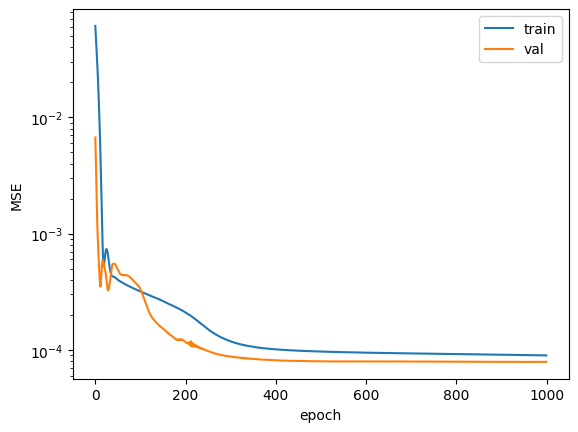

100%|██████████| 700/700 [00:04<00:00, 172.13it/s, lr=0.001, train=8.52e-5, val=7.5e-5]  


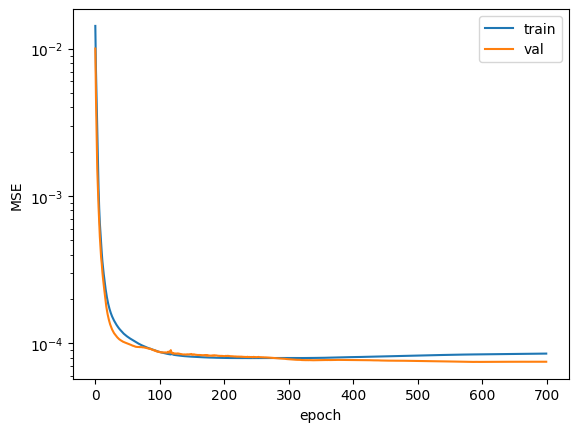

In [12]:
# Training 
weight_filename_fd = 'sp500_mlp_fd_weights.pth'
results_fd = train_sp500_fd(weight_filename_fd, train_set_fd, val_set_fd, test_set_fd, target_train_fd, target_val_fd, target_test_fd)
weight_filename_d = 'sp500_mlp_d_weights.pth'
results_d = train_sp500_d(weight_filename_d, train_set_d, val_set_d, test_set_d, target_train_d, target_val_d, target_test_d)


In [13]:
# Improvement of using fractional differetiation instead of integer differentiation
print("Results with fractional differentiation:")
print(f"Test MSE: {results_fd[0]:.6f}, Test RMSE: {results_fd[1]:.6f}, Test MAE: {results_fd[2]:.6f}")
print("Results with integer differentiation:")
print(f"Test MSE: {results_d[0]:.6f}, Test RMSE: {results_d[1]:.6f}, Test MAE: {results_d[2]:.6f}")


Results with fractional differentiation:
Test MSE: 0.000307, Test RMSE: 0.017522, Test MAE: 0.010825
Results with integer differentiation:
Test MSE: 0.000322, Test RMSE: 0.017939, Test MAE: 0.010085


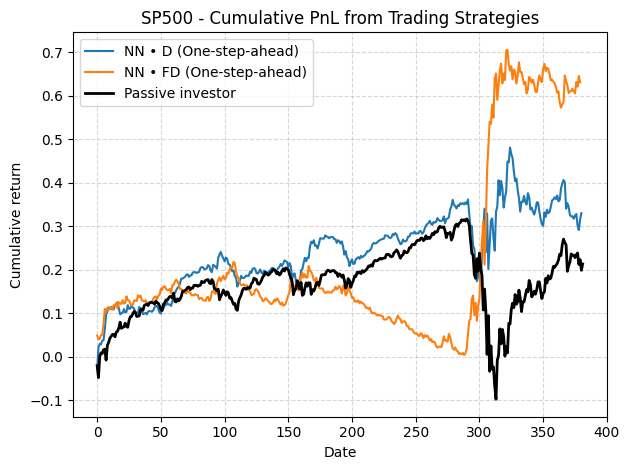

In [14]:
# Simulate trading strategies
cumulative_pnl_d = simulate_trading_sp500(results_d[-1])
cumulative_pnl_fd = simulate_trading_sp500(results_fd[-1])
# NN with differentiated data
plt.plot(cumulative_pnl_d, label='NN • D (One-step-ahead)')
# NN with fractionally differentiated data
plt.plot(cumulative_pnl_fd, label='NN • FD (One-step-ahead)')
# Passive investor	
plt.plot(sp500['Close_d'].iloc[-len(test_set_d)-1:].to_numpy().cumsum(), label="Passive investor", color="black", linestyle="-", linewidth=2)
plt.title(f"SP500 - Cumulative PnL from Trading Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="best")
plt.tight_layout()
plt.show()